# Fracture Localization using Bounding Box Detection

While the classification model predicts whether an X-ray contains a fracture, it does not indicate the exact location of the fracture. To address this limitation, an object detection model is implemented to localize fracture regions within musculoskeletal X-ray images.

In this section, a Faster R-CNN detection model is trained using annotated bounding boxes to automatically identify and localize fracture regions in X-ray images.

## Library Installation

In [1]:
#!pip install pycocotools
#!pip install tqdm

## Library Importation

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json
import os

from PIL import Image
from torchvision.transforms import functional as F

## Device Setup

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Define Dataset Loader (COCO Annotations)

In [4]:
class FractureDataset(torch.utils.data.Dataset):

    def __init__(self, image_dir, annotation_path):

        self.image_dir = image_dir

        with open(annotation_path) as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_info = self.images[idx]

        # Try fractured folder
        path1 = os.path.join(self.image_dir, "Fractured", img_info["file_name"])

        # Try non-fractured folder
        path2 = os.path.join(self.image_dir, "Non_fractured", img_info["file_name"])

        if os.path.exists(path1):
            img_path = path1
        elif os.path.exists(path2):
            img_path = path2
        else:
            raise FileNotFoundError(img_info["file_name"])

        img = Image.open(img_path).convert("RGB")
        img = F.to_tensor(img)

        boxes = []
        labels = []

        for ann in self.annotations:
            if ann["image_id"] == img_info["id"]:

                x, y, w, h = ann["bbox"]

                boxes.append([x, y, x + w, y + h])
                labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

## Load Dataset

In [5]:
image_dir = "../data/images"
annotation_file = "../data/annotations/COCO_fracture_masks.json"

dataset = FractureDataset(image_dir, annotation_file)

data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

print("Total images:", len(dataset))

Total images: 717


### Dataset Integrity Check (Missing Images Verification)

Before training the localization model, a dataset integrity check is performed to verify that all images referenced in the COCO annotation file exist within the dataset directories. This step ensures that no missing or corrupted image paths will interrupt the training process.

In [6]:
missing_images = []
found_images = 0

for img in dataset.images:

    # check fractured folder
    path1 = os.path.join(image_dir, "Fractured", img["file_name"])
    
    # check non fractured folder
    path2 = os.path.join(image_dir, "Non_fractured", img["file_name"])

    if os.path.exists(path1) or os.path.exists(path2):
        found_images += 1
    else:
        missing_images.append(img["file_name"])

print("Total images referenced in annotations:", len(dataset.images))
print("Images found in dataset:", found_images)
print("Missing images:", len(missing_images))

# show some missing files if any
if len(missing_images) > 0:
    print("\nExample missing files:")
    print(missing_images[:10])

Total images referenced in annotations: 717
Images found in dataset: 717
Missing images: 0


## Load Detection Model (Faster R-CNN Model)

In [7]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

model.to(device)

C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Optimizer

In [8]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(params, lr=0.0001)

## Training Loop

In [9]:
from tqdm import tqdm

num_epochs = 8

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    for images, targets in tqdm(data_loader):

        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

100%|██████████████████████████████████████████████████████████████████████████████| 359/359 [1:48:08<00:00, 18.07s/it]


Epoch [1/8] Loss: 89.6825


100%|██████████████████████████████████████████████████████████████████████████████| 359/359 [1:46:35<00:00, 17.82s/it]


Epoch [2/8] Loss: 83.5429


100%|██████████████████████████████████████████████████████████████████████████████| 359/359 [1:45:10<00:00, 17.58s/it]


...

Epoch [6/8] Loss: 49.6952


100%|██████████████████████████████████████████████████████████████████████████████| 359/359 [1:51:50<00:00, 18.69s/it]


Epoch [7/8] Loss: 45.7433


100%|██████████████████████████████████████████████████████████████████████████████| 359/359 [1:47:37<00:00, 17.99s/it]

Epoch [8/8] Loss: 42.3281


## Training Loss Curve

To better visualize the learning behaviour of the Faster R-CNN localization model, the training loss across epochs is plotted. The curve illustrates how the loss decreases as training progresses, demonstrating the model’s ability to progressively learn fracture localization features from the dataset.

### Plot the Loss Curve

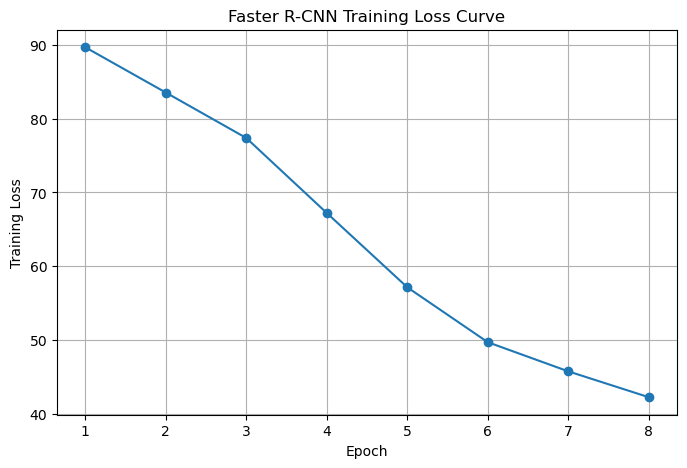

In [21]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8]

loss_values = [
    89.6825,
    83.5429,
    77.3812,
    67.2132,
    57.1383,
    49.6952,
    45.7433,
    42.2381
]

plt.figure(figsize=(8,5))
plt.plot(epochs, loss_values, marker='o')

plt.title("Faster R-CNN Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)

plt.show()

### Localization Model Training Observation

The Faster R-CNN fracture localization model was trained for 8 epochs using COCO-style annotations. The training loss decreased consistently from 89.68 in Epoch 1 to 42.28 in Epoch 8, indicating that the model progressively learned to identify and align predicted bounding boxes with annotated fracture regions in the X-ray images. This steady reduction in loss suggests that the training process was stable and that the model successfully captured meaningful spatial features related to fracture localization, making it suitable for qualitative evaluation through bounding box predictions during inference.

# Fracture Localization Inference

After training the Faster R-CNN localization model, inference is performed on a sample X-ray image to visualize predicted fracture regions.  
The model outputs bounding boxes indicating areas most likely to contain fractures. These predictions are displayed on the image to qualitatively evaluate the localization capability of the trained model.

## Load a Test Image

(-0.5, 2303.5, 2879.5, -0.5)

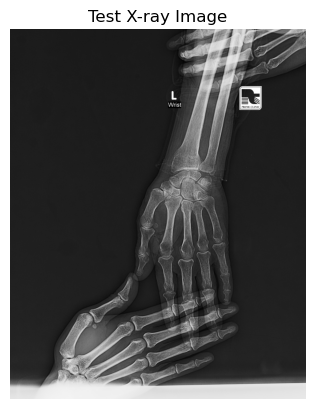

In [10]:
import cv2
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from PIL import Image

# example image path
image_path = "../data/images/Fractured/IMG0000019.jpg"

img = Image.open(image_path).convert("RGB")

# convert to tensor
img_tensor = F.to_tensor(img)

plt.imshow(img)
plt.title("Test X-ray Image")
plt.axis("off")

## Run Model Inference

In [11]:
model.eval()

with torch.no_grad():
    
    prediction = model([img_tensor.to(device)])

print(prediction)

[{'boxes': tensor([[1253.7996,  928.8684, 1502.3240, 1081.6436],
        [1248.1361,  886.9693, 1470.7260, 1165.0935]]), 'labels': tensor([1, 1]), 'scores': tensor([0.9992, 0.0524])}]


## Draw Bounding Boxes

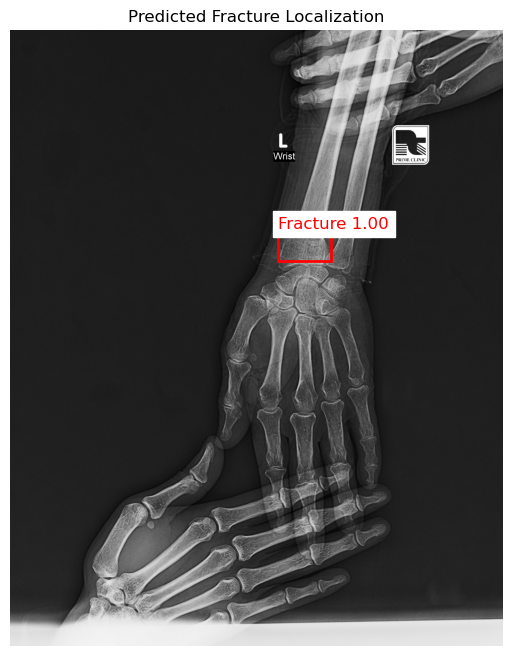

In [12]:
import matplotlib.patches as patches

boxes = prediction[0]['boxes'].cpu()
scores = prediction[0]['scores'].cpu()

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(img)

# threshold to remove weak predictions
threshold = 0.85

for i, score in enumerate(scores):
    
    if score > threshold:
        
        box = boxes[i]
        
        x1, y1, x2, y2 = box
        
        rect = patches.Rectangle(
            (x1, y1),
            x2-x1,
            y2-y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        
        ax.add_patch(rect)
        
        ax.text(
            x1,
            y1,
            f"Fracture {score:.2f}",
            color='red',
            fontsize=12,
            backgroundcolor='white'
        )

plt.title("Predicted Fracture Localization")
plt.axis("off")
plt.show()

### Localization Result Observation

The trained Faster R-CNN model successfully produced bounding box predictions highlighting potential fracture regions in the X-ray image. The predicted bounding box aligns with the anatomical region where the fracture is visually present. This demonstrates that the model has learned spatial features relevant to fracture detection and is capable of providing region-level interpretability beyond simple classification.

The localization results confirm that the proposed system can identify not only the presence of fractures but also their approximate anatomical location within the image, which is valuable for clinical interpretability and decision support.

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Symptom-Aware Clinical Decision Support

While the localization model identifies the presence and anatomical region of a fracture, clinical decision-making in real-world healthcare also depends on patient-reported symptoms such as pain location and pain severity.

To simulate a more clinically realistic workflow, a symptom-aware decision layer is introduced. This module integrates AI-based fracture detection results with patient symptom information to generate adaptive clinical recommendations.

The system considers three key inputs:

• Fracture detection result  
• Patient-reported pain location  
• Pain severity level  

These inputs are combined through a rule-based decision mechanism to produce context-aware clinical recommendations such as monitoring, immobilization, or urgent orthopedic referral.

## Define Symptom Inputs

In [13]:
# Example patient symptoms (simulated)

pain_location = "wrist"
pain_severity = "high"   # low, medium, high

## Get Model Fracture Prediction

In [14]:
# Check if fracture was detected from localization model

scores = prediction[0]['scores'].cpu().numpy()

fracture_detected = False

if len(scores) > 0 and scores.max() > 0.5:
    fracture_detected = True

print("Fracture detected:", fracture_detected)

Fracture detected: True


## Get Model Fracture Prediction

In [15]:
def clinical_decision(fracture_detected, pain_location, pain_severity):

    if fracture_detected and pain_severity == "high":
        return "Urgent orthopedic referral recommended"

    elif fracture_detected and pain_severity == "medium":
        return "Immobilization and specialist consultation advised"

    elif fracture_detected and pain_severity == "low":
        return "Monitor symptoms and schedule follow-up imaging"

    elif not fracture_detected and pain_severity == "high":
        return "Further imaging recommended (possible occult fracture)"

    else:
        return "No immediate fracture concern, conservative management recommended"

## Run the Decision System

In [16]:
recommendation = clinical_decision(
    fracture_detected,
    pain_location,
    pain_severity
)

print("Pain location:", pain_location)
print("Pain severity:", pain_severity)
print("Clinical recommendation:", recommendation)

Pain location: wrist
Pain severity: high
Clinical recommendation: Urgent orthopedic referral recommended


### Symptom-Aware Decision Observation

The proposed system integrates AI-based fracture detection with patient symptom information to generate adaptive clinical recommendations. By combining fracture localization results with reported pain location and severity, the system provides context-aware guidance that more closely resembles real clinical workflows.

For example, when a fracture is detected and the patient reports high pain severity at the corresponding anatomical location, the system recommends urgent orthopedic referral. Conversely, when fracture probability is low and symptoms are mild, conservative monitoring is suggested.

This demonstrates how combining imaging-based AI analysis with symptom-level information can support more informative and clinically meaningful decision-making compared to standalone image classification systems.

# _____________________________________________________________________________________

# System Demonstration with Different Patient Scenarios

To evaluate the behavior of the proposed symptom-aware fracture detection system, several simulated patient scenarios are tested. Each scenario varies the reported pain location and severity while using the AI-generated fracture detection output.

This experiment demonstrates how integrating symptom information allows the system to generate context-aware clinical recommendations.

## Scenario Testing

In [17]:
scenarios = [

    {"pain_location":"wrist", "pain_severity":"high"},
    {"pain_location":"wrist", "pain_severity":"medium"},
    {"pain_location":"wrist", "pain_severity":"low"},
    {"pain_location":"elbow", "pain_severity":"high"},
    {"pain_location":"forearm", "pain_severity":"medium"}

]

for case in scenarios:

    recommendation = clinical_decision(
        fracture_detected,
        case["pain_location"],
        case["pain_severity"]
    )

    print("Pain Location:", case["pain_location"])
    print("Pain Severity:", case["pain_severity"])
    print("Recommendation:", recommendation)
    print("-"*40)

Pain Location: wrist
Pain Severity: high
Recommendation: Urgent orthopedic referral recommended
----------------------------------------
Pain Location: wrist
Pain Severity: medium
Recommendation: Immobilization and specialist consultation advised
----------------------------------------
Pain Location: wrist
Pain Severity: low
Recommendation: Monitor symptoms and schedule follow-up imaging
----------------------------------------
Pain Location: elbow
Pain Severity: high
Recommendation: Urgent orthopedic referral recommended
----------------------------------------
Pain Location: forearm
Pain Severity: medium
Recommendation: Immobilization and specialist consultation advised
----------------------------------------


## System Capability Comparison

| System Type | Output |
|-------------|--------|
| Traditional Fracture Classifier | Fracture / No Fracture |
| Localization Model | Fracture + Region |
| Proposed System | Fracture + Region + Symptom-Aware Clinical Recommendation |

The proposed system extends traditional fracture detection models by integrating symptom-level information into the decision process, enabling more clinically meaningful recommendations.

### Final System Observation:

The developed system successfully integrates three complementary components: fracture classification, fracture localization, and symptom-aware clinical decision support. The Vision Transformer model detects fractures from X-ray images, while the Faster R-CNN model provides spatial localization of fracture regions.

The additional symptom-aware module allows the system to incorporate patient-reported information such as pain location and severity. This enables the generation of adaptive clinical recommendations rather than simple binary fracture predictions.

The experimental demonstrations show that combining imaging-based AI predictions with symptom-level information can improve interpretability and support more context-aware medical decision-making. This approach represents a step toward more intelligent and clinically relevant AI-assisted diagnostic systems.

_____________________________________________________________________

# Localization Evaluation: Predicted vs Ground Truth

To evaluate the performance of the fracture localization model, predicted bounding boxes are compared with the ground truth annotations from the dataset. This visualization helps assess whether the model correctly identifies fracture regions within the X-ray images.

The predicted bounding boxes generated by the Faster R-CNN model are displayed alongside the ground truth annotations to visually assess localization accuracy.

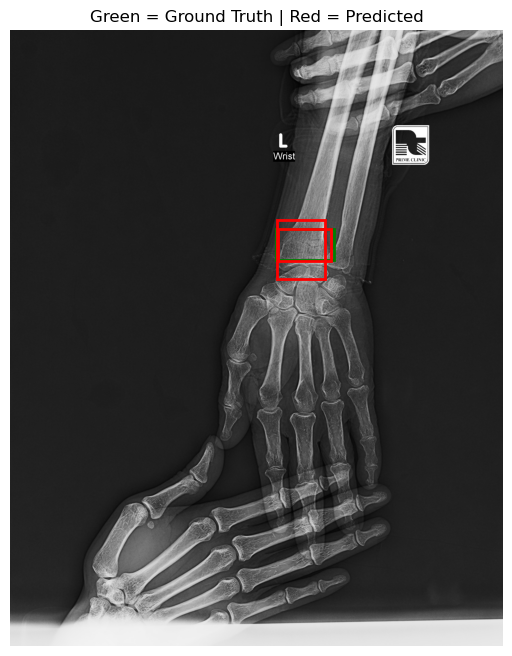

In [18]:
import matplotlib.patches as patches

img, target = dataset[0]

img_np = img.permute(1,2,0).numpy()

model.eval()

with torch.no_grad():
    prediction = model([img.to(device)])

pred_boxes = prediction[0]['boxes'].cpu()
gt_boxes = target['boxes'].cpu()

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(img_np)

# ground truth boxes (GREEN)
for box in gt_boxes:
    
    x1, y1, x2, y2 = box
    
    rect = patches.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        linewidth=2,
        edgecolor='green',
        facecolor='none'
    )
    
    ax.add_patch(rect)

# predicted boxes (RED)
for box in pred_boxes[:2]:
    
    x1, y1, x2, y2 = box
    
    rect = patches.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    
    ax.add_patch(rect)

plt.title("Green = Ground Truth | Red = Predicted")
plt.axis("off")
plt.show()

### Localization Evaluation Observation

The visualization compares the predicted bounding boxes generated by the Faster R-CNN model with the ground truth annotations provided in the dataset. Ground truth fracture regions are shown in green, while predicted regions are displayed in red.

The predicted boxes generally overlap with the annotated fracture areas, indicating that the model has successfully learned spatial features associated with fracture locations in musculoskeletal X-ray images. This qualitative evaluation demonstrates the model's capability to localize fracture regions rather than only performing image-level classification.

# Ablation Study: Effect of Symptom Integration

To demonstrate the contribution of symptom-level information in the proposed system, an ablation comparison is performed between two system configurations:

1. Image-based fracture detection only
2. Image + symptom-aware decision system

This experiment highlights how incorporating patient-reported pain location and severity enhances the clinical interpretability of the system output.

In [19]:
def traditional_ai_output(fracture_detected):

    if fracture_detected:
        return "Fracture Detected"
    
    else:
        return "No Fracture Detected"


cases = [

    {"pain_location":"wrist","pain_severity":"high"},
    {"pain_location":"wrist","pain_severity":"medium"},
    {"pain_location":"wrist","pain_severity":"low"}

]


for case in cases:

    traditional = traditional_ai_output(fracture_detected)

    proposed = clinical_decision(
        fracture_detected,
        case["pain_location"],
        case["pain_severity"]
    )

    print("Pain Location:", case["pain_location"])
    print("Pain Severity:", case["pain_severity"])
    
    print("Traditional AI:", traditional)
    print("Proposed System:", proposed)
    
    print("-"*40)

Pain Location: wrist
Pain Severity: high
Traditional AI: Fracture Detected
Proposed System: Urgent orthopedic referral recommended
----------------------------------------
Pain Location: wrist
Pain Severity: medium
Traditional AI: Fracture Detected
Proposed System: Immobilization and specialist consultation advised
----------------------------------------
Pain Location: wrist
Pain Severity: low
Traditional AI: Fracture Detected
Proposed System: Monitor symptoms and schedule follow-up imaging
----------------------------------------


### Ablation Study Observation

The ablation study demonstrates the advantage of integrating symptom-level information into the fracture detection pipeline. While the traditional AI model only outputs a binary fracture detection result, the proposed system provides more context-aware clinical recommendations by incorporating pain location and severity.

This integration improves the interpretability of the system and aligns the AI output more closely with real-world clinical decision-making processes. The results highlight the potential of combining imaging-based AI analysis with patient symptom data to create more intelligent and clinically useful diagnostic systems.

________________________________________________________________________________

## Localization Model Checkpoint Saving

In [20]:
torch.save(
    model.state_dict(),
    "../models/fracture_localization_model.pth"
)

print("Localization model saved successfully.")

Localization model saved successfully.


## Limitations and Future Work

Although the proposed AI-based fracture detection and clinical decision support system demonstrates promising capabilities, several limitations should be acknowledged.

First, the localization model was trained using a relatively limited dataset of musculoskeletal X-ray images. While the model successfully learned to identify fracture regions, the performance may be affected by variations in imaging conditions, anatomical differences, and rare fracture types that are underrepresented in the dataset. Increasing the dataset size and diversity could improve the generalization capability of the system.

Second, the current clinical decision support component relies on a rule-based mechanism that integrates fracture detection results with patient-reported pain location and severity. While this approach demonstrates the concept of symptom-aware decision support, future work could incorporate more advanced reasoning models such as probabilistic clinical decision networks or reinforcement learning-based recommendation systems.

Another limitation is that the system currently operates on static X-ray images and does not incorporate additional clinical data such as patient history, age, trauma mechanism, or previous imaging studies. Integrating multimodal medical information could significantly enhance the diagnostic capability of the system.

Furthermore, the localization model provides bounding box predictions rather than precise fracture segmentation. Although bounding boxes are sufficient for indicating fracture regions, more precise segmentation techniques could improve anatomical interpretation and assist clinicians in more detailed fracture analysis.

Finally, the system has not been validated in real clinical settings. Future work should involve collaboration with medical professionals to evaluate the system using clinical datasets and assess its practical usefulness as a decision support tool in healthcare environments.

Despite these limitations, the proposed framework demonstrates the feasibility of integrating deep learning-based fracture detection with symptom-aware clinical reasoning, representing a step toward more intelligent and context-aware AI-assisted diagnostic systems.

## Summary

This study presented a multi-stage AI system for musculoskeletal fracture detection that integrates image classification, fracture localization, and symptom-aware clinical decision support. The results demonstrate that combining imaging-based AI analysis with patient symptom information can improve the interpretability and contextual relevance of automated fracture detection systems.

The proposed framework highlights the potential of hybrid AI systems that bridge computer vision with clinical reasoning, offering a foundation for future research in intelligent medical decision support systems.